# Capstone Project 2: Predicting Movie Profitability

# Part 3: Exploratory Data Analysis (EDA)

# 1. Introduction

In this section, we will explore the movie_data_cleaned.csv dataset to identify patterns, trends, and correlations that influence movie profitability.

### Key Questions:

- Does a higher budget guarantee a higher ROI?

- Which genres have the highest probability of success?

- Is there a "best month" to release a movie?

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load the cleaned data
df = pd.read_csv('movie_data_cleaned.csv')

# Dataset overview
print(f"Data Shape: {df.shape}")
display(df.head())

Data Shape: (6420, 20)


,Movie Name,Release Date,Production Budget (USD),Domestic Gross (USD),Worldwide Gross (USD),MPAA Rating,Running Time (minutes),Franchise,Keywords,Source,Genre,Production Method,Creative Type,Production/Financing Companies,Production Countries,Languages,ROI,is_profitable,Release Year,Release Month
0,Star Wars Ep. VII: The Force Awakens,2015-12-16,533200000,936662225,2056046835,PG-13,136.0,1,"Space Opera,Good vs. Evil,Delayed Sequel,Inter...",Original Screenplay,Adventure,"Animation,Live Action",Science Fiction,"Lucasfilm,Bad Robot",United States,English,3.856052,1,2015,12
1,Avatar: The Way of Water,2022-12-09,460000000,684075767,2315589775,PG-13,190.0,1,"Action Adventure,Delayed Sequel,Humans as Alie...",Original Screenplay,Action,"Animation,Live Action",Science Fiction,"Lightstorm Entertainment,20th Century Studios,...",United States,English,5.033891,1,2022,12
2,Indiana Jones and the Dial of Destiny,2023-06-28,402300000,174480468,383963057,PG-13,142.0,1,"1960s,Space Program,Nazis Outside of World War...",Original Screenplay,Adventure,Live Action,Historical Fiction,"Lucasfilm,Walt Disney Pictures,Paramount Pictures",United States,English,0.954420,0,2023,6
3,Avengers: Endgame,2019-04-23,400000000,858373000,2748242781,PG-13,181.0,1,"Ensemble,Marvel Comics,Animal Lead,Non-Chronol...",Based on Comic/Graphic Novel,Action,"Animation,Live Action",Super Hero,Marvel Studios,United States,English,6.870607,1,2019,4
4,Mission: Impossible—The Final Reckoning,2025-05-21,400000000,0,0,Unrated,105.0,0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0.000000,0,2025,5


## 2. Univariate Analysis

We start by examining the distribution of our key numerical variables: `Production Budget` and `ROI`.

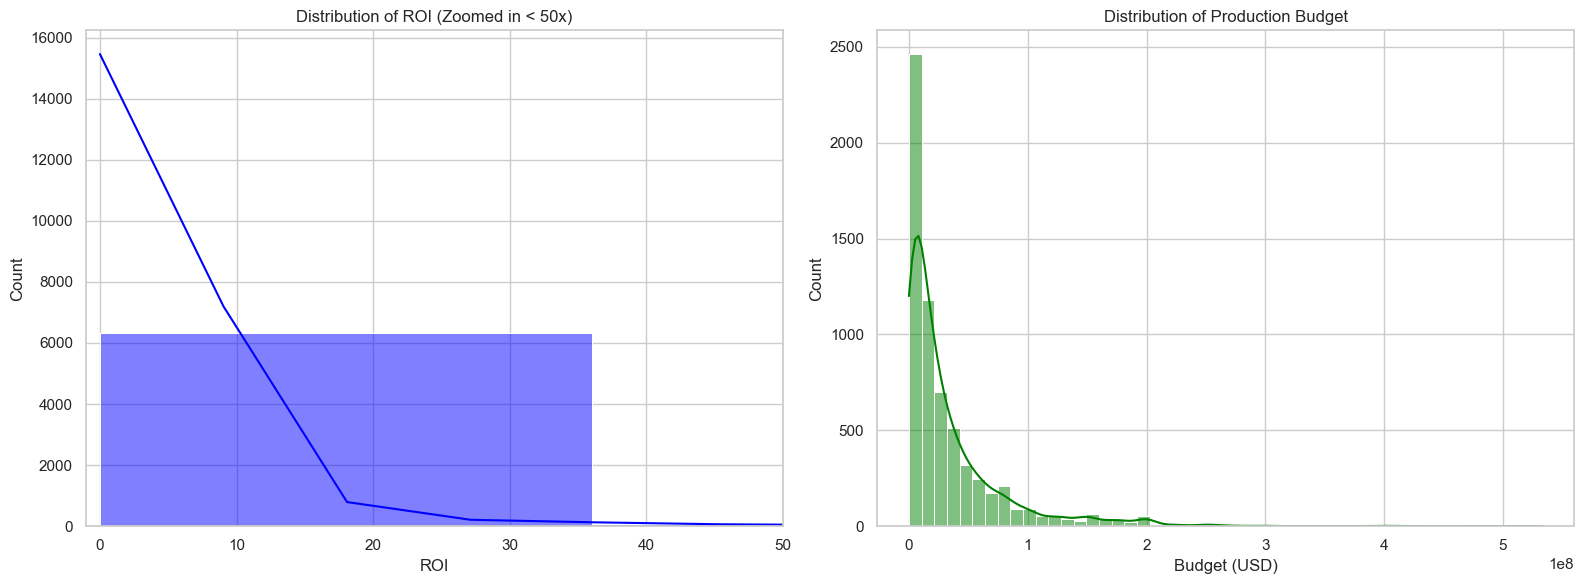

ROI Summary Stats:
count    6420.000000
mean        4.611192
std        27.301096
min         0.000000
25%         0.510399
50%         1.727687
75%         3.806668
max      1800.000000
Name: ROI, dtype: float64


In [4]:
# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: ROI Distribution (Zoomed in to show the bulk of data)
sns.histplot(data=df, x='ROI', bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of ROI (Zoomed in < 50x)')
axes[0].set_xlim(-1, 50) # Most movies make between -1x and 50x

# Plot 2: Production Budget Distribution
sns.histplot(data=df, x='Production Budget (USD)', bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Production Budget')
axes[1].set_xlabel('Budget (USD)')

plt.tight_layout()
plt.show()

# Print summary statistics
print("ROI Summary Stats:")
print(df['ROI'].describe())

### Observation:

* **Right Skewed**: Most movies are flops or modest hits, but a few lottery tickets make billions. Since the industry **"break even"** point is **2.5x**, with the median of 1.73 means more then 50% of the movies actually lose money.

## 3. Bivariate Analysis

Now we explore relationships between variables. Specifically, we want to know if **Production Budget** or **Genre** are strong predictors of Profitability.

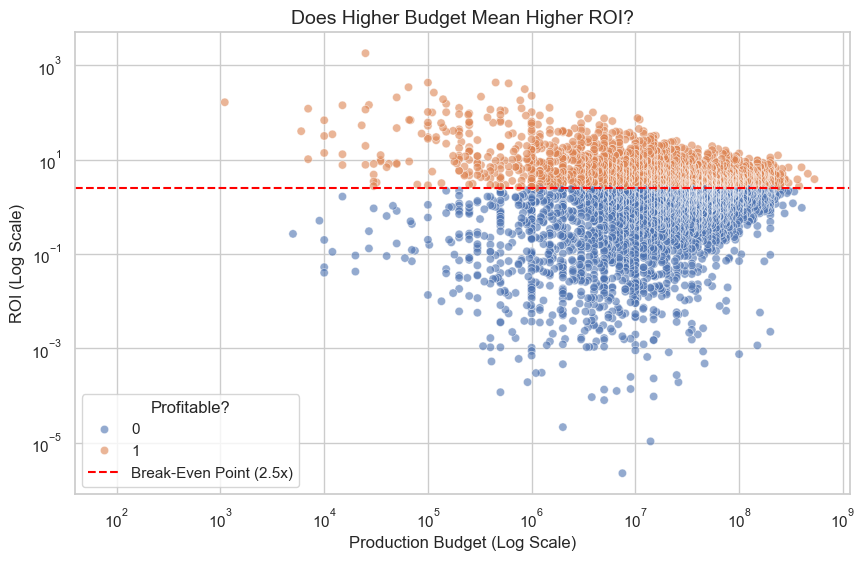

In [5]:
# Create a scatter plot of Budget vs. ROI
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Production Budget (USD)', y='ROI', hue='is_profitable', alpha=0.6)

# Add a horizontal line at ROI = 2.5 (Break Even Point)
plt.axhline(y=2.5, color='red', linestyle='--', label='Break-Even Point (2.5x)')

plt.title('Does Higher Budget Mean Higher ROI?', fontsize=14)
plt.xscale('log') # Use log scale for budget because values range from $1k to $400M
plt.yscale('log') # Use log scale for ROI to see the clusters better
plt.xlabel('Production Budget (Log Scale)')
plt.ylabel('ROI (Log Scale)')
plt.legend(title='Profitable?')
plt.show()

### Observation:

* **No Linear Correlation:** There is no clear upward trend indicating that spending more money guarantees a higher return. In fact, many high-budget films land below the break-even line.

* **The Cone Shape:**
    * **Low Budget Films:** Exhibit extreme variance. They include the biggest flops (ROI ~0) and the massive viral hits (ROI > 50x).
    * **High Budget Films:** Exhibit low variance. They rarely reach massive ROI multiples (it's hard to make 10x on a $200M budget), but they also rarely flop completely. High budget acts as a "floor" for revenue, but a "ceiling" for ROI.

C:\Users\miket\AppData\Local\Temp\ipykernel_9320\779730312.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ROI', y='Genre', order=genre_order, palette='viridis')
c:\Users\miket\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


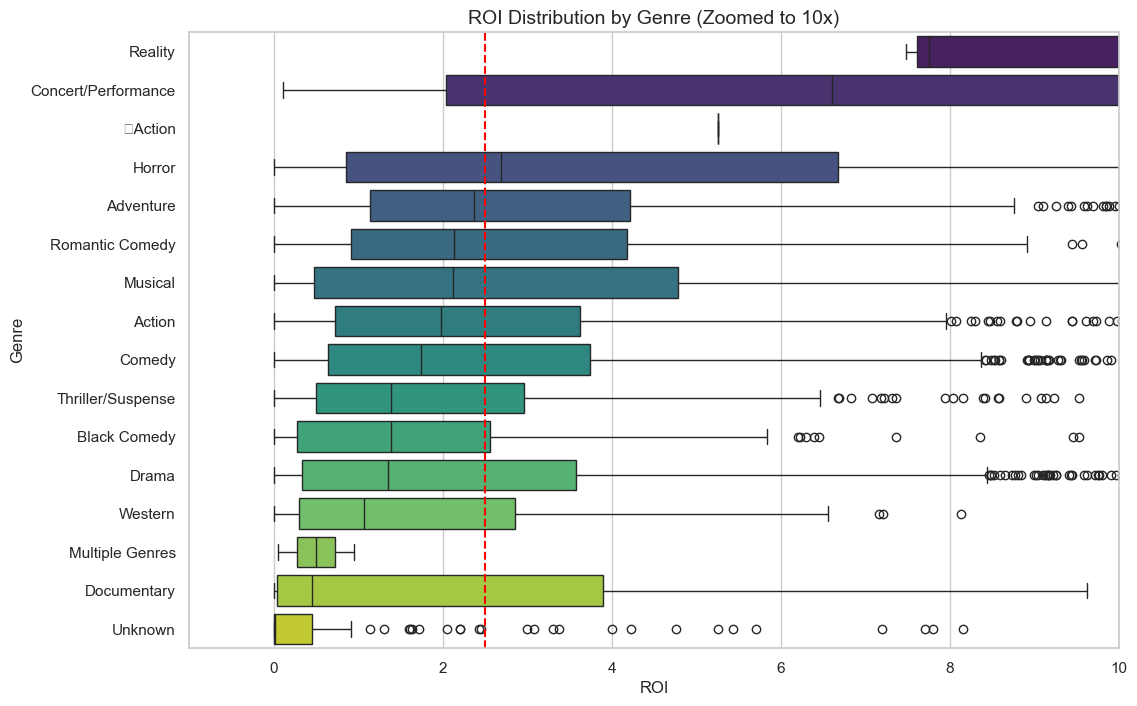

In [10]:
# Calculate median ROI by Genre to sort the plot
genre_order = df.groupby('Genre')['ROI'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='ROI', y='Genre', order=genre_order, palette='viridis')

# Zoom in to see the boxes clearly (ignoring the 1800x outliers for a moment)
plt.xlim(-1, 10)
plt.axvline(x=2.5, color='red', linestyle='--', label='Break-Even Point (2.5x)')
plt.title('ROI Distribution by Genre (Zoomed to 10x)', fontsize=14)
plt.xlabel('ROI')
plt.ylabel('Genre')
plt.show()

### Observation:

* **High ROI Potential:** Genres like **Horror** and **Thriller** often show high median ROIs. This is likely because they can be produced on a extremely low budgets, making it easier to cross the profitability threshold.

* **Volume vs. Efficiency:** While **Action** and **Adventure** movies likely generate the most gross revenue (dollars), their massive budgets make them less efficient (ROI) compared to niche genres.

* **Outliers:** Almost every genre has massive outliers, confirming that a "hit" can come from anywhere, but the probability of success is structurally higher in lower-budget genres.

## 4. Multivariate Analysis

We will use a correlation matrix to identify how numerical variables relate to one another. We are specifically interested in which features have a strong correlation with `ROI`.

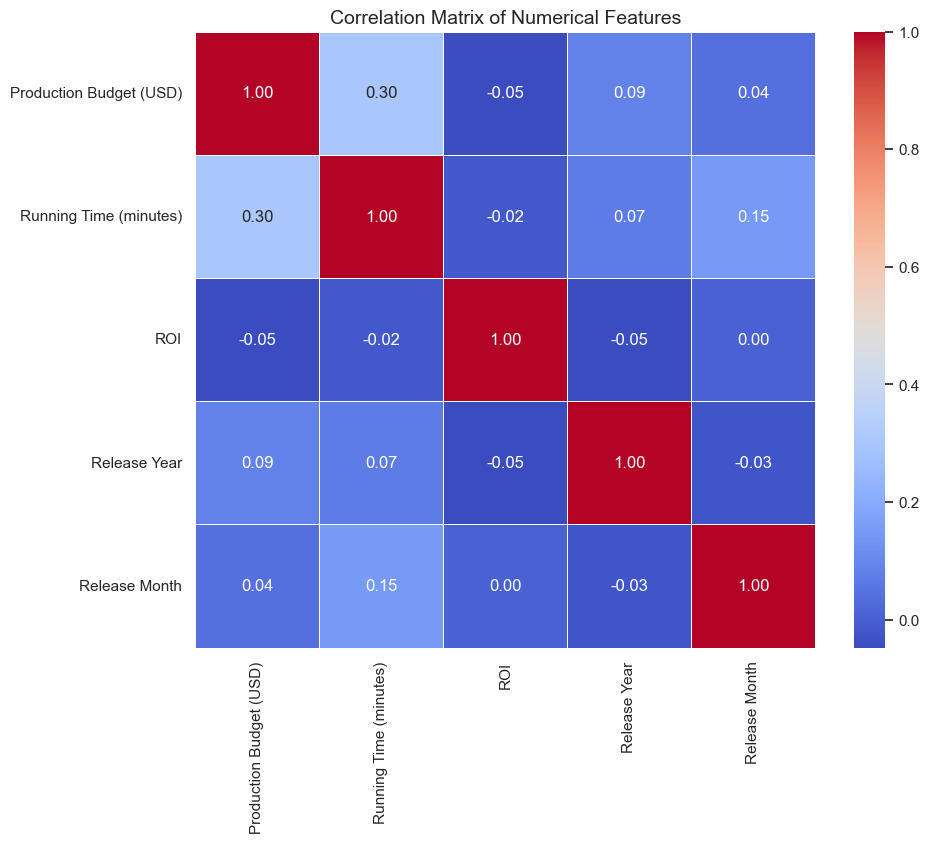

In [11]:
# Select only numerical columns for correlation
numerical_cols = ['Production Budget (USD)', 'Running Time (minutes)', 'ROI', 'Release Year', 'Release Month']
corr_matrix = df[numerical_cols].corr()

# Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.show()

### Observation:

* **Budget vs. ROI (Negative Correlation):** The slight negative correlation confirms our scatter plot finding: throwing money at a movie does not linearly increase its profitability ratio.

* **Weak Drivers:** The overall lack of strong dark red/blue squares (correlations > 0.5) tells us that ROI cannot be predicted by a single simple variable.

## 5. Time Series Analysis

We analyze the "Seasonality" of movie profitability. Do movies released in specific months have a higher median ROI?

C:\Users\miket\AppData\Local\Temp\ipykernel_9320\455759222.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_roi.index, y=monthly_roi.values, palette='magma')


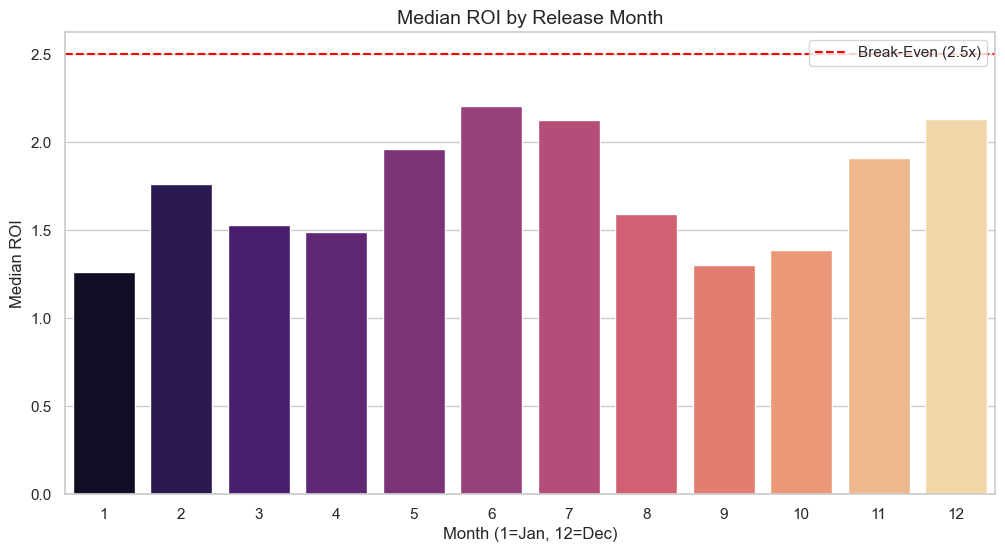

In [ ]:
# Calculate Median ROI for each month
monthly_roi = df.groupby('Release Month')['ROI'].median()

# Create a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_roi.index, y=monthly_roi.values, palette='magma')

# Add labels
plt.title('Median ROI by Release Month', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Median ROI')
plt.axhline(y=2.5, color='red', linestyle='--', label='Break-Even (2.5x)')
plt.legend()
plt.show()

### Observation:

* **The "Blockbuster" Windows:** We see clear spikes in Median ROI during **June/July** (Summer) and **November/December** (Holiday Season).

* **The Sobering Reality:** Critically, the Median ROI for **every single month** is below the 2.5x Break-Even line. This proves that theatrical profitability is not the "norm"—it is the exception. Even in the best months, more than 50% of movies fail to profit from ticket sales alone.

## 6. Conclusion

Our Exploratory Data Analysis has revealed that the movie industry is characterized by **high risk and high skew**.

**Key Findings:**
1.  **High Failure Rate:** The Median ROI is consistently below the 2.5x break-even threshold across all months and most budgets. Profitability is the exception, not the rule.

2.  **Budget is a Safety Net, not a Multiplier:** Higher budgets reduce the risk of a total disaster (flooring the revenue), but they significantly cap the ROI upside. Low-budget films offer the highest potential returns but come with extreme variance.

3.  **Seasonality and Genre Matters:** Release timing and Genre are stronger indicators of potential ROI than raw budget.
